In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib/x86_64-linux-gnu/libm.so.6: version `GLIBC_2.29' not found (required by /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:72: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:99: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace:

In [2]:
from celcomen.models.celcomen import celcomen
from celcomen.models.simcomen import simcomen
from celcomen.training_plan.train import train
from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [3]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool, edge_index):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        # compute the edges as two cell widths apart so 30µm
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

In [5]:
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# add necessary attributes from metadata
avis.obs['sample_id'] = 'sample'
avis.obsm['spatial'] = avis.obs[['imagerow','imagecol']].values
sc.pp.filter_genes(avis, min_cells=10)

from scipy.sparse import csr_matrix
# convert the gene expression data to numpy and sphere normalize
# > lymph node
x = torch.from_numpy(avis.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis.X = csr_matrix(torch.div(x, norm_factor))
avis.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')
avis.shape

(4035, 19813)

In [6]:
# check out the shape of the item
avis_storage = avis.copy()
avis_storage.shape

(4035, 19813)

In [7]:
import time
# define the parameters of the model
learning_rate = 1e-4
n_neighbors = 6
zmft_scalar = 1e-1
seed = 0
epochs = 100

In [8]:
# determine the overall edge_index
pos = torch.from_numpy(avis.obsm["spatial"])
edge_index = torch.from_numpy(np.array(np.where(kneighbors_graph(avis.obsm['spatial'], \
n_neighbors=6, include_self=False).toarray() == 1))).to('cuda')

In [9]:
# derive the statistics
device = 'cuda'
df_stat = pd.DataFrame(columns=['device','n_genes','seed','duration'])
for n_genes in [200, 500, 1000, 2000, 5000, 10000]:
    for seed in range(5):
        # set the seed
        np.random.seed(seed)
        # decide on the cells to analyze
        genes = np.random.choice(avis_storage.var.index, size=n_genes, replace=False)
        # subset accordingly
        avis = avis_storage[:, genes].copy()
        avis.obs['sample'] = 'sample'
        avis.write_h5ad('data/avis.h5')
        # instantiate the model, input and output will be the same
        loader = get_dataset_loaders('data/avis.h5', 'sample', 6, device, True, edge_index=edge_index)
        model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
        input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
        input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
        model.set_g2g(torch.from_numpy(input_g2g))
        model.set_g2g_intra(torch.from_numpy(input_g2g))
        model.to(device)
        start_time = time.time()
        losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=1, device=device)
        duration = time.time() - start_time
        df_stat.loc[df_stat.shape[0]] = device, n_genes, seed, duration

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 200], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 41.45it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 200], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 56.41it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 200], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



...

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 10000], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [02:19<00:00,  1.39s/it]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 10000], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [02:18<00:00,  1.38s/it]


ValueError: Cannot take a larger sample than population when 'replace=False'

In [29]:
# derive the statistics
device = 'cuda'
# df_stat = pd.DataFrame(columns=['device','n_genes','seed','duration'])
for n_genes in [100]:
    for seed in range(5):
        # set the seed
        np.random.seed(seed)
        # decide on the cells to analyze
        genes = np.random.choice(avis_storage.var.index, size=n_genes, replace=False)
        # subset accordingly
        avis = avis_storage[:, genes].copy()
        avis.obs['sample'] = 'sample'
        avis.write_h5ad('data/avis.h5')
        # instantiate the model, input and output will be the same
        loader = get_dataset_loaders('data/avis.h5', 'sample', 6, device, True, edge_index=edge_index)
        model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
        input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
        input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
        model.set_g2g(torch.from_numpy(input_g2g))
        model.set_g2g_intra(torch.from_numpy(input_g2g))
        model.to(device)
        start_time = time.time()
        losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=1, device=device)
        duration = time.time() - start_time
        df_stat.loc[df_stat.shape[0]] = device, n_genes, seed, duration

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 100], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|████████████████████████████████████████| 100/100 [00:00<00:00, 101.64it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 100], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|████████████████████████████████████████| 100/100 [00:00<00:00, 106.51it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 100], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|████████████████████████████████████████| 100/100 [00:00<00:00, 103.38it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 100], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|████████████████████████████████████████| 100/100 [00:00<00:00, 102.83it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 100], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



100%|████████████████████████████████████████| 100/100 [00:00<00:00, 103.64it/s]


In [30]:
df_stat = df_stat.sort_values('n_genes')

/loc/scratch/8916647/ipykernel_31262/1239071870.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='n_genes', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_31262/1239071870.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(x='n_genes', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_31262/1239071870.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


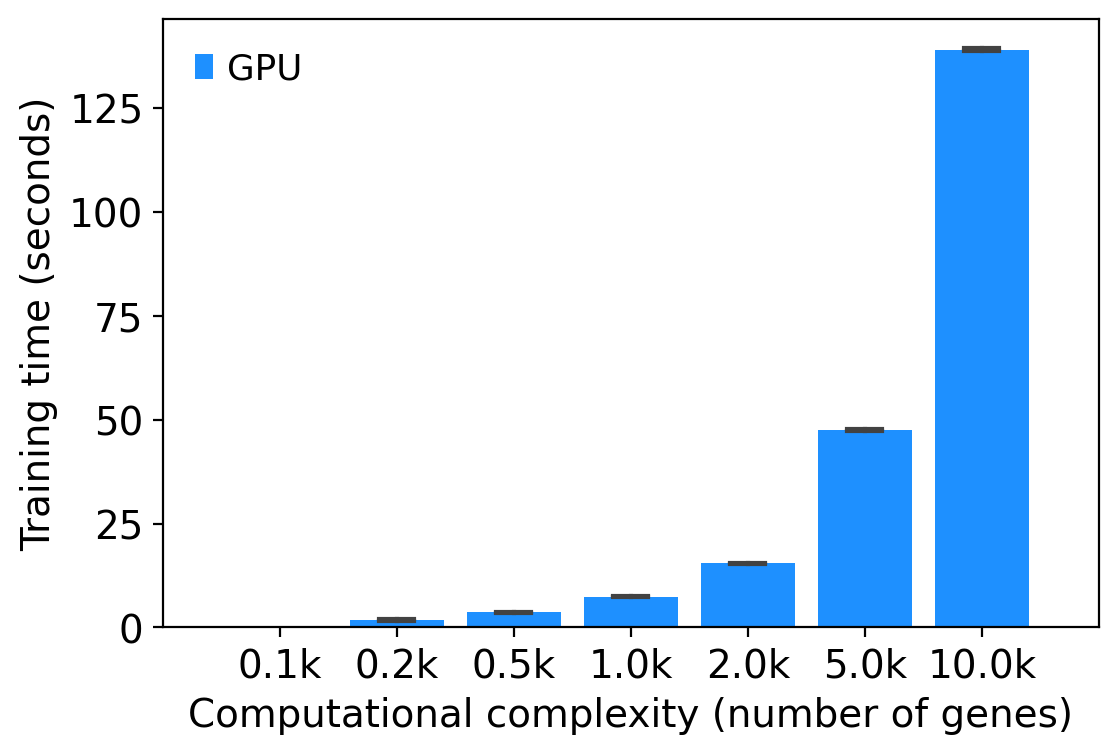

In [33]:
# show the values
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
data = df_stat.loc[df_stat['n_genes'] >= 200].copy(); data['n_genes'] /= 1000
sns.barplot(x='n_genes', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
            saturation=1, palette=['dodgerblue'], hue_order=['cuda'],
            order=[0.1, 0.2, 0.5, 1, 2, 5, 10])
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlim(-1, 7)
ax.set_xlabel('Computational complexity (number of genes)')
ax.set_ylabel('Training time (seconds)')
ax.legend(frameon=False)
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[1]\
.get_children()[0].set_text('GPU')

In [34]:
df_stat.to_csv('tmp.genes.csv')

In [35]:
df_agg = df_stat.groupby(['device','n_genes']).mean().reset_index().\
pivot_table(index='n_genes', columns='device', values='duration')

1    7.466332
2    0.597856
dtype: float64


/loc/scratch/8916647/ipykernel_31262/20939071.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


(-5.991858208179474, 146.59338756799698)

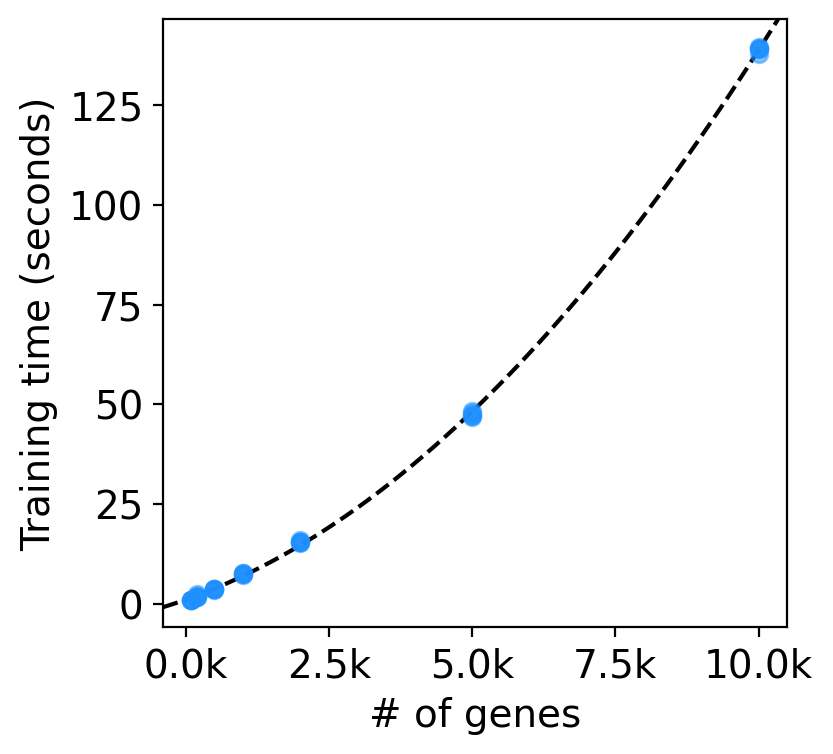

In [42]:
# grab the relevant data
mask = df_stat['device'] == 'cuda'
xs, ys = df_stat.loc[mask, 'n_genes'] / 1e3, df_stat.loc[mask, 'duration']
# report on the RMSEs
rmses = pd.Series()
for deg in range(1, 2+1):
    model = np.polynomial.Polynomial(deg)
    model = model.fit(xs, ys, deg)
    rmse = np.sqrt(np.mean((ys - model(xs)) ** 2))
    rmses.loc[deg] = rmse
print(rmses)
# plot the model and data
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
ax.scatter(xs, ys, color='dodgerblue', alpha=0.5)
xlim = ax.get_xlim(); ylim = ax.get_ylim()
xl, yl = model.linspace(domain=xlim)
ax.plot(xl, yl, color='k', linestyle='--', zorder=0)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlabel('# of genes')
ax.set_ylabel('Training time (seconds)')
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

In [39]:
model(30) / 60

15.620736418971715